In [ ]:
#fault tolerance means if our code is crash in somehow during execution so  it resume from the crash point not from the starting one here is the best example of this one


In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import time

In [14]:
class FaultState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str

In [ ]:
def step_1(state:FaultState)->FaultState:
    print("step_1 completed")
    return {'step1':'done',"input":state['input']}
def step_2(state:FaultState)->FaultState:
    print("step_2  hanging  .... now manually interrupt from the notebook")
    time.sleep(30)
    return {'step2':'done'}
def step_3(state:FaultState)->FaultState:
    print("step_3 completed")
    return{'step3':'done'}

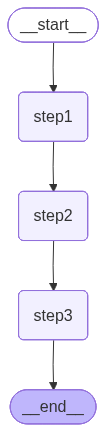

In [16]:
graph = StateGraph(FaultState)
graph.add_node("step1",step_1)
graph.add_node("step2",step_2)
graph.add_node("step3",step_3)


graph.add_edge(START,"step1")
graph.add_edge("step1","step2")
graph.add_edge("step2","step3")
graph.add_edge("step3",END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow


In [17]:
config = {'configurable':{"thread_id":"thread_1"}}
try:
    print("Running graph: please  manually interepted here")
    result = workflow.invoke({"input":"start"},config=config)
except KeyboardInterrupt:
    print("kernel is intruppted")

Running graph: please  manually interepted here
step_1 completed


KeyError: 'intput'